Task is Denoising

--- STEP 1: MNIST PRE-TRAINING ---
Epoch 01 | Train MSE: 0.0673 | Val MSE: 0.0345 | Encoder LR: 0.001
Epoch 02 | Train MSE: 0.0225 | Val MSE: 0.0175 | Encoder LR: 0.001
Epoch 03 | Train MSE: 0.0159 | Val MSE: 0.0147 | Encoder LR: 0.001
Epoch 04 | Train MSE: 0.0141 | Val MSE: 0.0136 | Encoder LR: 0.001
Epoch 05 | Train MSE: 0.0130 | Val MSE: 0.0128 | Encoder LR: 0.001
Epoch 06 | Train MSE: 0.0124 | Val MSE: 0.0122 | Encoder LR: 0.001
Epoch 07 | Train MSE: 0.0120 | Val MSE: 0.0118 | Encoder LR: 0.001
Epoch 08 | Train MSE: 0.0117 | Val MSE: 0.0116 | Encoder LR: 0.001
Epoch 09 | Train MSE: 0.0114 | Val MSE: 0.0115 | Encoder LR: 0.001
Epoch 10 | Train MSE: 0.0113 | Val MSE: 0.0113 | Encoder LR: 0.001
Epoch 11 | Train MSE: 0.0111 | Val MSE: 0.0111 | Encoder LR: 0.001
Epoch 12 | Train MSE: 0.0110 | Val MSE: 0.0111 | Encoder LR: 0.001
Epoch 13 | Train MSE: 0.0109 | Val MSE: 0.0110 | Encoder LR: 0.001
Epoch 14 | Train MSE: 0.0108 | Val MSE: 0.0109 | Encoder LR: 0.001
Epoch 15

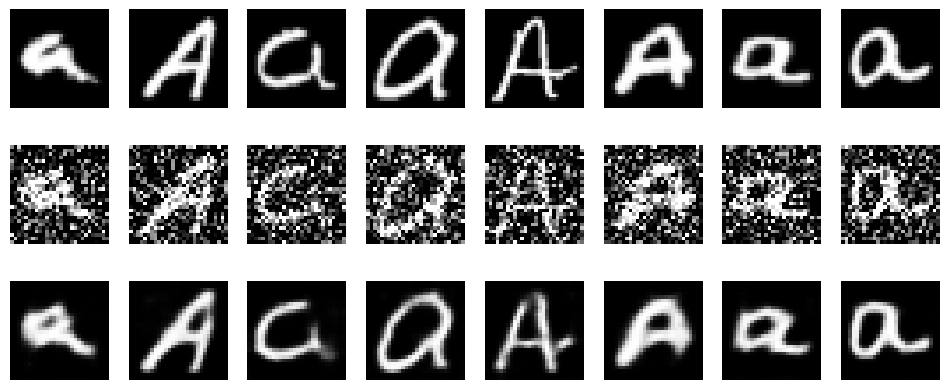


--- STEP 3: TRAINING FROM SCRATCH ---
Epoch 01 | Train MSE: 0.1752 | Val MSE: 0.1153 | Encoder LR: 0.001
Epoch 02 | Train MSE: 0.0976 | Val MSE: 0.0886 | Encoder LR: 0.001
Epoch 03 | Train MSE: 0.0877 | Val MSE: 0.0858 | Encoder LR: 0.001
Epoch 04 | Train MSE: 0.0862 | Val MSE: 0.0851 | Encoder LR: 0.001
Epoch 05 | Train MSE: 0.0857 | Val MSE: 0.0847 | Encoder LR: 0.001
Epoch 06 | Train MSE: 0.0853 | Val MSE: 0.0844 | Encoder LR: 0.001
Epoch 07 | Train MSE: 0.0850 | Val MSE: 0.0842 | Encoder LR: 0.001
Epoch 08 | Train MSE: 0.0847 | Val MSE: 0.0839 | Encoder LR: 0.001
Epoch 09 | Train MSE: 0.0845 | Val MSE: 0.0836 | Encoder LR: 0.001
Epoch 10 | Train MSE: 0.0841 | Val MSE: 0.0832 | Encoder LR: 0.001
Epoch 11 | Train MSE: 0.0834 | Val MSE: 0.0824 | Encoder LR: 0.001
Epoch 12 | Train MSE: 0.0825 | Val MSE: 0.0812 | Encoder LR: 0.001
Epoch 13 | Train MSE: 0.0810 | Val MSE: 0.0789 | Encoder LR: 0.001
Epoch 14 | Train MSE: 0.0775 | Val MSE: 0.0739 | Encoder LR: 0.001
Epoch 15 | Train MSE: 0

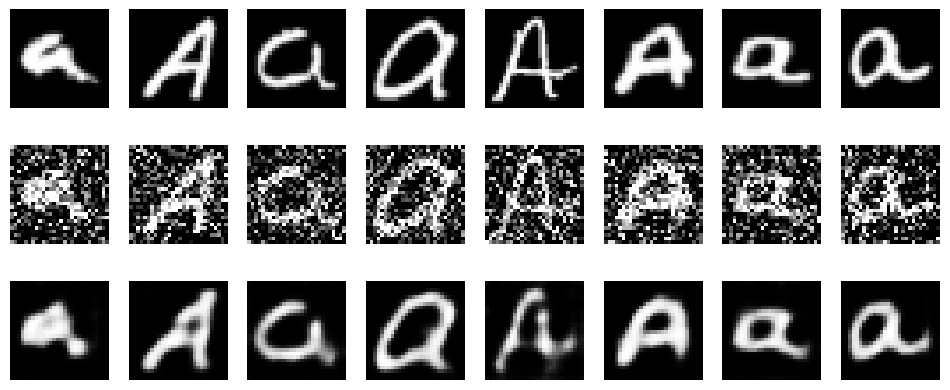

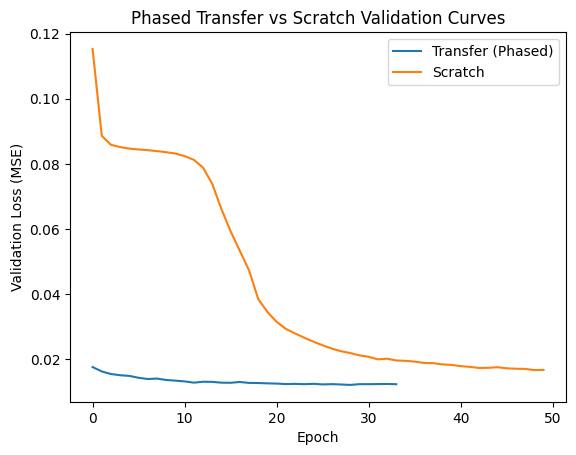


BEST STRATEGY SELECTED: Transfer

--- RETRAINING PRODUCTION MODEL ON FULL DATASET (TRAIN + VAL) ---
Optimal training budget: 29 epochs
Retrain Epoch 01/29 | Aggregated Loss: 0.0198
Retrain Epoch 02/29 | Aggregated Loss: 0.0165
Retrain Epoch 03/29 | Aggregated Loss: 0.0154
Retrain Epoch 04/29 | Aggregated Loss: 0.0150
Retrain Epoch 05/29 | Aggregated Loss: 0.0145
>>> Epoch 6: Fine-tuning encoder...
Retrain Epoch 06/29 | Aggregated Loss: 0.0142
Retrain Epoch 07/29 | Aggregated Loss: 0.0136
Retrain Epoch 08/29 | Aggregated Loss: 0.0134
Retrain Epoch 09/29 | Aggregated Loss: 0.0129
Retrain Epoch 10/29 | Aggregated Loss: 0.0128
Retrain Epoch 11/29 | Aggregated Loss: 0.0128
Retrain Epoch 12/29 | Aggregated Loss: 0.0125
Retrain Epoch 13/29 | Aggregated Loss: 0.0125
Retrain Epoch 14/29 | Aggregated Loss: 0.0123
Retrain Epoch 15/29 | Aggregated Loss: 0.0121
Retrain Epoch 16/29 | Aggregated Loss: 0.0121
Retrain Epoch 17/29 | Aggregated Loss: 0.0121
Retrain Epoch 18/29 | Aggregated Loss: 0.0120


In [1]:
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset, ConcatDataset
from torchvision import transforms
from torchvision.datasets import MNIST, EMNIST

# ============================================================
# 1. REPRODUCIBILITY & DEVICE
# ============================================================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything()

device = torch.device(
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available() 
    else "cpu"
)

# ============================================================
# 2. DATA PREPARATION 
# ============================================================
# No standard normalization used: preserves [0, 1] range for Sigmoid layer compatibility
emnist_transform = transforms.Compose([
    lambda img: transforms.functional.rotate(img, -90),
    lambda img: transforms.functional.hflip(img),
    transforms.ToTensor()
])

mnist_transform = transforms.ToTensor()

mnist_full = MNIST(root="data", train=True, transform=mnist_transform, download=True)
mnist_test = MNIST(root="data", train=False, transform=mnist_transform, download=True)

mnist_generator = torch.Generator().manual_seed(42)
mnist_train, mnist_val = random_split(mnist_full, [55000, 5000], generator=mnist_generator)

fraction = 0.02
emnist_full_train = EMNIST(root="data", split="letters", train=True, transform=emnist_transform, download=True)
emnist_test = EMNIST(root="data", split="letters", train=False, transform=emnist_transform, download=True)

subset_size = int(len(emnist_full_train) * fraction)
subset_generator = torch.Generator().manual_seed(42)
indices = torch.randperm(len(emnist_full_train), generator=subset_generator)[:subset_size]
emnist_subset = Subset(emnist_full_train, indices)

train_size = int(0.8 * subset_size)
val_size = subset_size - train_size

# Decoupled seed (43) protects against structural domain index cross-contamination
emnist_generator = torch.Generator().manual_seed(43)
emnist_train, emnist_val = random_split(
    emnist_subset,
    [train_size, val_size],
    generator=emnist_generator
)

batch_size = 128
loader_args = {"batch_size": batch_size, "num_workers": 0}

mnist_train_loader = DataLoader(mnist_train, shuffle=True, **loader_args)
mnist_val_loader   = DataLoader(mnist_val, shuffle=False, **loader_args)

emnist_train_loader = DataLoader(emnist_train, shuffle=True, **loader_args)
emnist_val_loader   = DataLoader(emnist_val, shuffle=False, **loader_args)

# ============================================================
# 3. MODEL ARCHITECTURE 
# ============================================================
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),  # 28x28 -> 14x14
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # 14x14 -> 7x7
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, latent_dim)
        )

        self.decoder_input = nn.Linear(latent_dim, 32 * 7 * 7)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 1, 3, padding=1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        z = self.encoder(x)
        x = self.decoder_input(z)
        x = x.view(-1, 32, 7, 7)
        return self.decoder(x)

# ============================================================
# 4. UTILITIES
# ============================================================
def add_noise(x, noise_factor=0.5):
    noise = torch.randn_like(x) * noise_factor
    return torch.clamp(x + noise, 0., 1.)

class EarlyStopping:
    def __init__(self, model, patience=5):
        self.patience = patience
        self.counter = 0
        self.best_loss = float("inf")
        self.best_weights = copy.deepcopy(model.state_dict())

    def __call__(self, model, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            self.best_weights = copy.deepcopy(model.state_dict())
            return False
        else:
            self.counter += 1
            return self.counter >= self.patience

    def restore(self, model):
        model.load_state_dict(self.best_weights)

# ============================================================
# 5. TRAINING ENGINE
# ============================================================
def set_encoder_lr(optimizer, lr):
    optimizer.param_groups[0]["lr"] = lr
    
def run_experiment(
    model, train_loader, val_loader, denoising=False, epochs=20,
    encoder_lr=1e-3, unfreeze_epoch=None, fine_tune_lr=1e-4
):
    criterion = nn.MSELoss()
    
    # Computational fix: If initial LR is 0, freeze parameters to save backpropagation time
    if encoder_lr == 0.0:
        for param in model.encoder.parameters():
            param.requires_grad = False
            
    optimizer = torch.optim.Adam([
        {"params": model.encoder.parameters(), "lr": encoder_lr},
        {"params": model.decoder_input.parameters(), "lr": 1e-3},
        {"params": model.decoder.parameters(), "lr": 1e-3},
    ])
    
    es = EarlyStopping(model, patience=5)
    history = {"train": [], "val": []}
    model.to(device)

    for epoch in range(epochs):
        # Scheduled Phased Unfreezing
        if unfreeze_epoch is not None and epoch == unfreeze_epoch:
            print(f"\n>>> Epoch {epoch+1}: Fine-tuning encoder...")
            for param in model.encoder.parameters():
                param.requires_grad = True
            set_encoder_lr(optimizer, fine_tune_lr)
            
        # Training Phase
        model.train()
        t_loss = 0
        for x, _ in train_loader:
            x = x.to(device)
            inp = add_noise(x) if denoising else x
            
            optimizer.zero_grad()
            out = model(inp)
            loss = criterion(out, x)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()
        
        # Validation Phase
        model.eval()
        v_loss = 0
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(device)
                inp = add_noise(x) if denoising else x
                v_loss += criterion(model(inp), x).item()
        
        t_loss /= len(train_loader)
        v_loss /= len(val_loader)
        history["train"].append(t_loss)
        history["val"].append(v_loss)
        
        enc_lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch+1:02d} | Train MSE: {t_loss:.4f} | Val MSE: {v_loss:.4f} | Encoder LR: {enc_lr}")
        
        if es(model, v_loss): 
            print("Early stopping triggered.")
            break

    es.restore(model)
    return history

def visualize(model, dataset, denoising=False):
    model.eval()
    x = torch.stack([dataset[i][0] for i in range(8)]).to(device)
    inp = add_noise(x) if denoising else x
    with torch.no_grad(): 
        out = model(inp)
    
    fig, axs = plt.subplots(3, 8, figsize=(12, 5))
    for i in range(8):
        axs[0,i].imshow(x[i][0].cpu(), cmap='gray'); axs[0,i].axis('off')
        axs[1,i].imshow(inp[i][0].cpu(), cmap='gray'); axs[1,i].axis('off')
        axs[2,i].imshow(out[i][0].cpu(), cmap='gray'); axs[2,i].axis('off')
    plt.show()

# ============================================================
# 6. EXECUTION & VALIDATION SWEEP
# ============================================================
DENOISE = True
# Fixed string evaluation precedence bug using f-string interpolation
print(f"Task is {'Denoising' if DENOISE else 'Reconstructing'}")

# --- STEP 1: MNIST PRE-TRAINING ---
print("\n--- STEP 1: MNIST PRE-TRAINING ---")
mnist_ae = Autoencoder(latent_dim=64)
run_experiment(
    model=mnist_ae, train_loader=mnist_train_loader, val_loader=mnist_val_loader,
    denoising=DENOISE, epochs=25
)
torch.save(mnist_ae.state_dict(), "mnist_base.pt")

# --- STEP 2: TRANSFER WITH PHASED UNFREEZING ---
print("\n--- STEP 2: TRANSFER LEARNING (Phased) ---")
transfer_ae = Autoencoder(latent_dim=64)
transfer_ae.load_state_dict(torch.load("mnist_base.pt"))

transfer_hist = run_experiment(
    model=transfer_ae, train_loader=emnist_train_loader, val_loader=emnist_val_loader,
    denoising=DENOISE, epochs=50, encoder_lr=0.0, unfreeze_epoch=5, fine_tune_lr=3e-4,
)
visualize(transfer_ae, emnist_test, denoising=DENOISE)

# --- STEP 3: SCRATCH ---
print("\n--- STEP 3: TRAINING FROM SCRATCH ---")
scratch_ae = Autoencoder(latent_dim=64)
scratch_hist = run_experiment(
    model=scratch_ae, train_loader=emnist_train_loader, val_loader=emnist_val_loader,
    denoising=DENOISE, epochs=50, encoder_lr=1e-3,
)
visualize(scratch_ae, emnist_test, denoising=DENOISE)

# --- CRITERION COMPARISON ---
plt.plot(transfer_hist["val"], label="Transfer (Phased)")
plt.plot(scratch_hist["val"], label="Scratch")
plt.title("Phased Transfer vs Scratch Validation Curves")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss (MSE)")
plt.legend()
plt.show()

# ============================================================
# 7. PRODUCTION RETRAINING & HOLD-OUT TESTING
# ============================================================
transfer_best_loss = min(transfer_hist["val"])
scratch_best_loss = min(scratch_hist["val"])

if transfer_best_loss < scratch_best_loss:
    best_strategy = "Transfer"
    winning_hist = transfer_hist
else:
    best_strategy = "Scratch"
    winning_hist = scratch_hist

print("\n" + "="*50)
print(f"BEST STRATEGY SELECTED: {best_strategy}")
print("="*50)
print(f"\n--- RETRAINING PRODUCTION MODEL ON FULL DATASET (TRAIN + VAL) ---")

full_emnist_subset = ConcatDataset([emnist_train, emnist_val])
full_subset_loader = DataLoader(full_emnist_subset, shuffle=True, **loader_args)

# Identify the exact epoch where optimization hit its lowest validation MSE
optimal_epochs = np.argmin(winning_hist["val"]) + 1
print(f"Optimal training budget: {optimal_epochs} epochs")

champion_model = Autoencoder(latent_dim=64)
criterion = nn.MSELoss()

if best_strategy == "Transfer":
    champion_model.load_state_dict(torch.load("mnist_base.pt"))
    for param in champion_model.encoder.parameters():
        param.requires_grad = False
    optimizer = torch.optim.Adam([
        {"params": champion_model.encoder.parameters(), "lr": 0.0},
        {"params": champion_model.decoder_input.parameters(), "lr": 1e-3},
        {"params": champion_model.decoder.parameters(), "lr": 1e-3},
    ])
    unfreeze_epoch = 5
    fine_tune_lr = 3e-4
else:
    optimizer = torch.optim.Adam([
        {"params": champion_model.encoder.parameters(), "lr": 1e-3},
        {"params": champion_model.decoder_input.parameters(), "lr": 1e-3},
        {"params": champion_model.decoder.parameters(), "lr": 1e-3},
    ])
    unfreeze_epoch = None

champion_model.to(device)

for epoch in range(optimal_epochs):
    if unfreeze_epoch is not None and epoch == unfreeze_epoch:
        print(f">>> Epoch {epoch+1}: Fine-tuning encoder...")
        for param in champion_model.encoder.parameters():
            param.requires_grad = True
        set_encoder_lr(optimizer, fine_tune_lr)

    champion_model.train()
    total_loss = 0.0
    for x, _ in full_subset_loader:
        x = x.to(device)
        inp = add_noise(x) if DENOISE else x

        optimizer.zero_grad()
        out = champion_model(inp)
        loss = criterion(out, x)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Retrain Epoch {epoch+1:02d}/{optimal_epochs:02d} | Aggregated Loss: {total_loss / len(full_subset_loader):.4f}")

# --- FINAL EVALUATION ON INDEPENDENT TEST SET ---
champion_model.eval()
emnist_test_loader = DataLoader(emnist_test, shuffle=False, **loader_args)
final_test_mse = 0.0

with torch.no_grad():
    for x, _ in emnist_test_loader:
        x = x.to(device)
        inp = add_noise(x) if DENOISE else x
        final_test_mse += criterion(champion_model(inp), x).item()

final_test_mse /= len(emnist_test_loader)

print("\n" + "="*50)
print("FINAL HOLDOUT TEST BENCHMARK SUMMARY")
print("="*50)
print(f"Selected Strategy   -> {best_strategy}")
print(f"Final Test MSE      -> {final_test_mse:.5f}")
print("="*50)

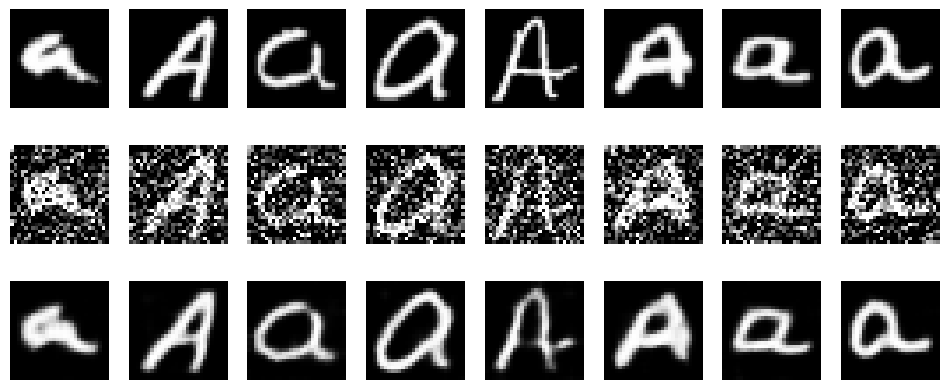

In [2]:
visualize(champion_model, emnist_test, denoising=DENOISE)
